In [2]:
#objectif metier : predire si une tumeur est malign ou benign

In [3]:
#importation des bibliotheques
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('breast-cancer.csv')

In [5]:
#affichage des 5 premieres lignes du dataset
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
#affichage des informations du dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [7]:
#affichage de la forme du dataset
df.shape

(569, 32)

In [8]:
#affichage du type de chaque colonne
df.dtypes

id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [9]:
#gestion des valeurs manquantes
#afficher la somme des valeurs manquantes par colonne
df.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [10]:
#compter le nombre de valeurs manquantes dans tout le dataset
df.isnull().sum().sum()

0

In [11]:
#Pourcentage de valeurs manquantes par colonne
df.isnull().mean() * 100
#df.isnull().sum()*100/len(df)

id                         0.0
diagnosis                  0.0
radius_mean                0.0
texture_mean               0.0
perimeter_mean             0.0
area_mean                  0.0
smoothness_mean            0.0
compactness_mean           0.0
concavity_mean             0.0
concave points_mean        0.0
symmetry_mean              0.0
fractal_dimension_mean     0.0
radius_se                  0.0
texture_se                 0.0
perimeter_se               0.0
area_se                    0.0
smoothness_se              0.0
compactness_se             0.0
concavity_se               0.0
concave points_se          0.0
symmetry_se                0.0
fractal_dimension_se       0.0
radius_worst               0.0
texture_worst              0.0
perimeter_worst            0.0
area_worst                 0.0
smoothness_worst           0.0
compactness_worst          0.0
concavity_worst            0.0
concave points_worst       0.0
symmetry_worst             0.0
fractal_dimension_worst    0.0
dtype: f

In [12]:
#detecter ou sont les valeurs manquantes    
df[df.isnull().any(axis=1)]

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst


In [13]:
#connaitre la distribution des valeurs de la colonne/variable cible 'diagnosis'
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [14]:
#connaitre la distribution des valeurs de la colonne/variable cible 'diagnosis' en pourcentage
df['diagnosis'].value_counts(normalize=True)*100 

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

In [15]:
#suupression de la colonne 'id' qui n'apporte pas d'information pertinente pour la classification
df.drop('id', axis=1, inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [17]:
#encodage de la variable cible Malignant=1 et Benign=0
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int32  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [19]:
#verification des doublons
df.duplicated().sum()

0

In [20]:
#calcul des statistiques descriptives
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [21]:
#identification des features avec la plus grande variance
variance = df.var()
features_with_high_variance = variance[variance > variance.mean()].index
features_with_high_variance 

Index(['area_mean', 'area_worst'], dtype='object')

In [22]:
#calcul du skewness pour chaque feature
skewness = df.skew()


In [23]:
df.groupby('diagnosis').mean()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,,,,,,,,,,,,,,,,,,,,,
0,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442
1,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530


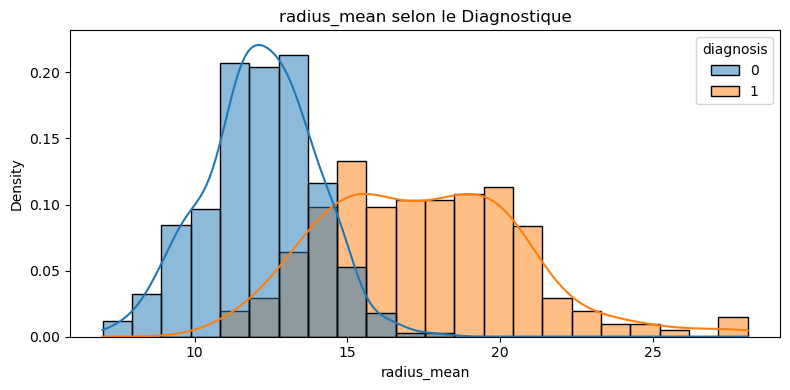

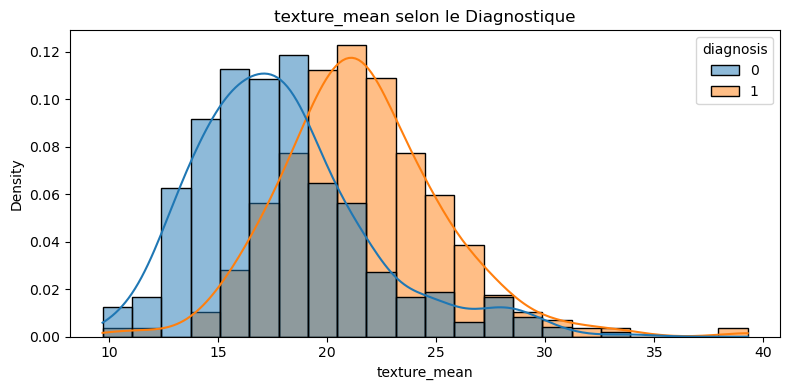

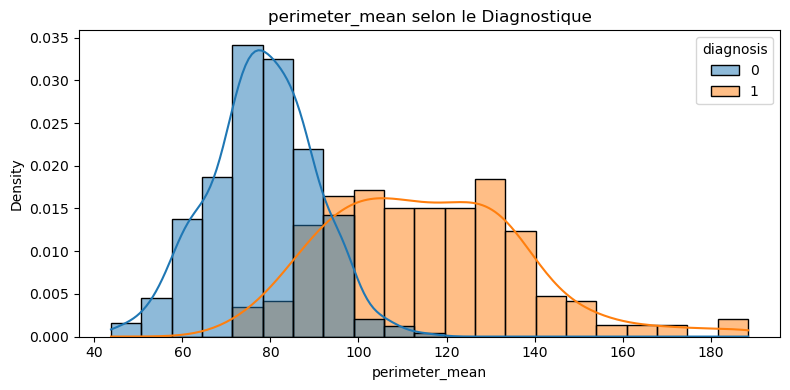

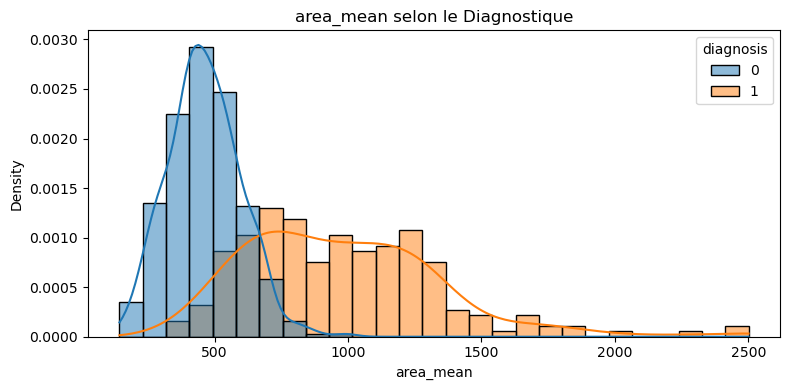

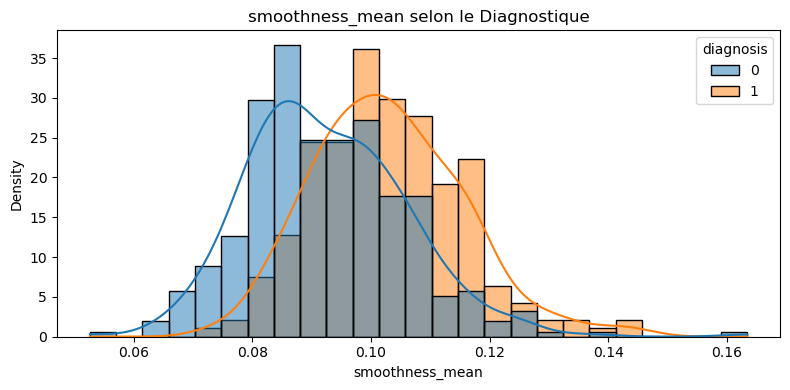

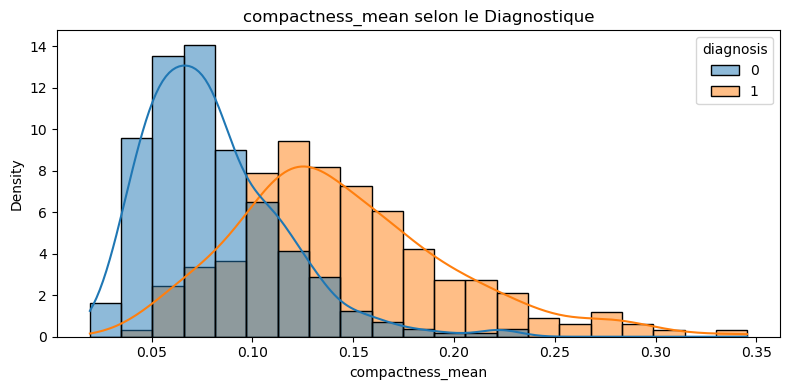

In [24]:
#histogramme de 6 features importantes avec KDE
important_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean']
for feature in important_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, hue='diagnosis', kde=True, stat="density", common_norm=False)
    plt.title(f'{feature} selon le Diagnostique')
    plt.tight_layout()
    plt.show()

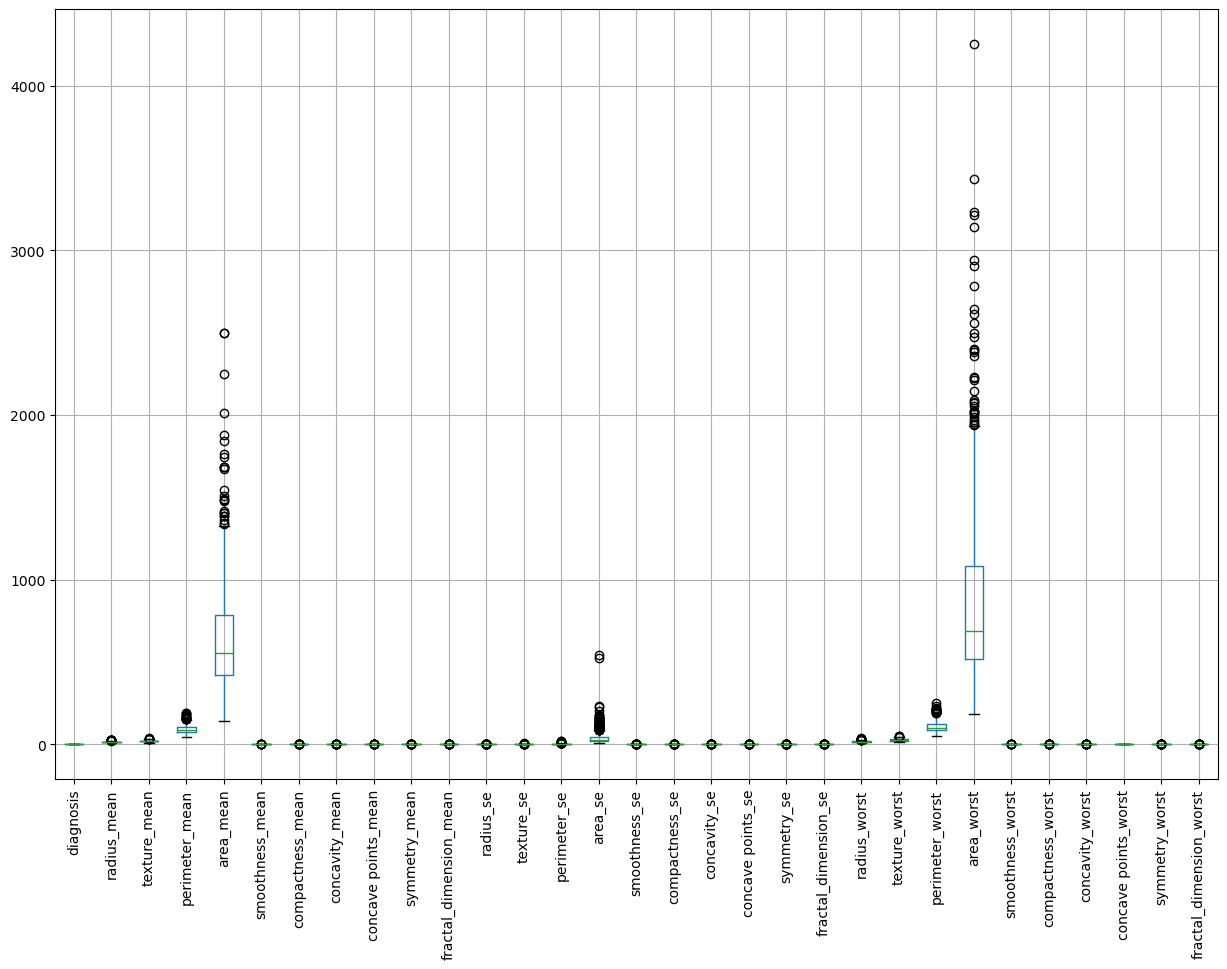

In [25]:
#detection des outliers avec boxplot
plt.figure(figsize=(15,10))
df.boxplot()
plt.xticks(rotation=90)
plt.show()

Text(0.5, 1.0, 'Distribution de la variable cible')

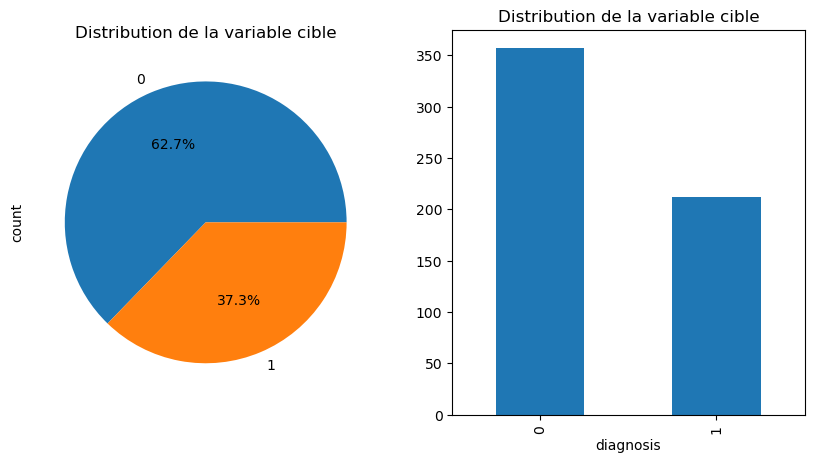

In [26]:
#distribution de la variable cible avec pie chart et bar plot
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
df['diagnosis'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution de la variable cible')
plt.subplot(1,2,2)
df['diagnosis'].value_counts().plot(kind='bar')
plt.title('Distribution de la variable cible')

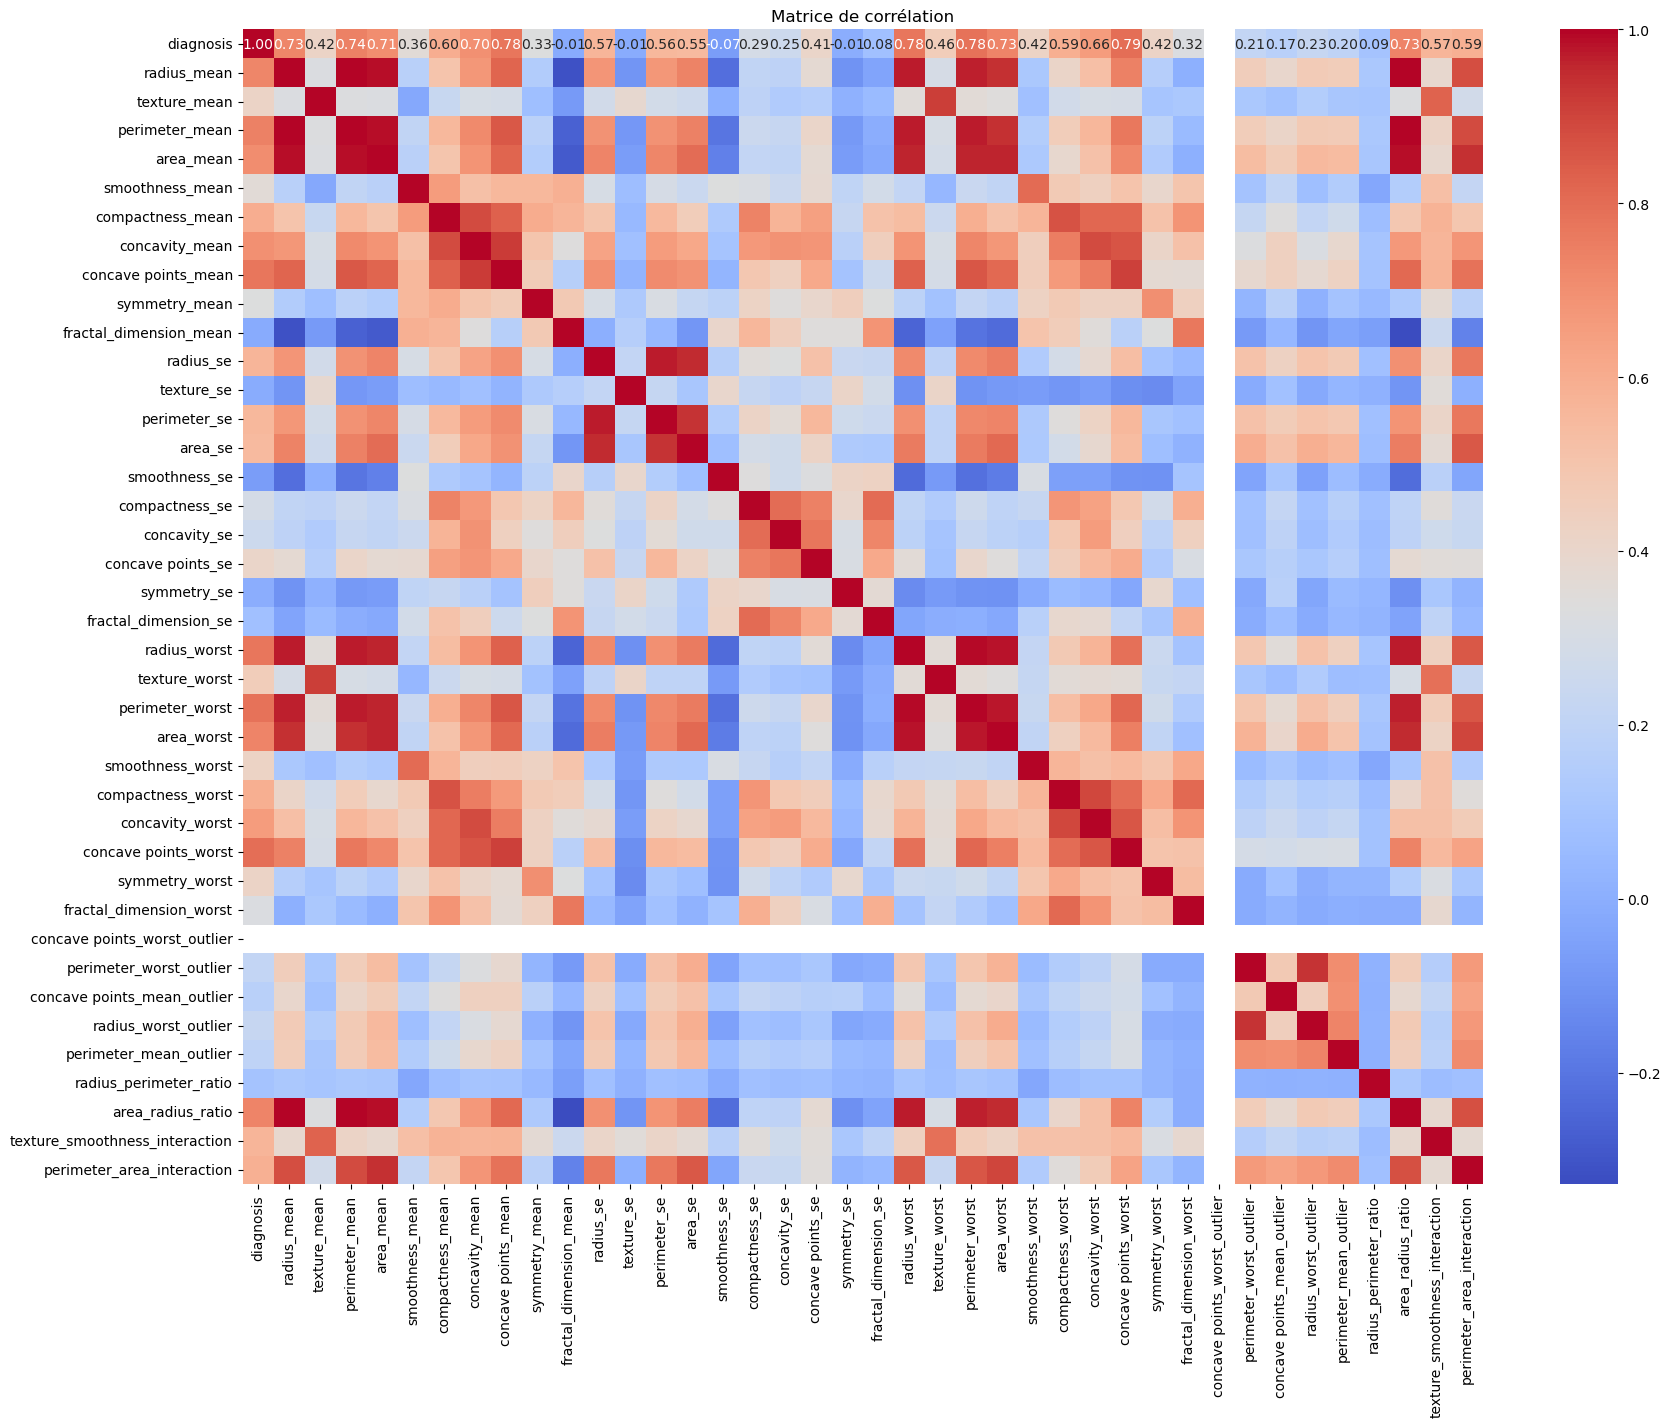

In [52]:
#matrice de correlation
plt.figure(figsize=(20,15))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matrice de corrélation') 
plt.show()

In [53]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst',
       'concave points_worst_outlier', 'perimeter_worst_outlier',
       'concave points_mean_outlier', 'radius_worst_outlier',
       'perimeter_mean_outlier', 'radius_perimeter_ratio', 'area_radius_ratio',
       'texture_smoothness_interaction', 'perimeter_area_interaction'],
      dtype='object')

concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis, dtype: float64


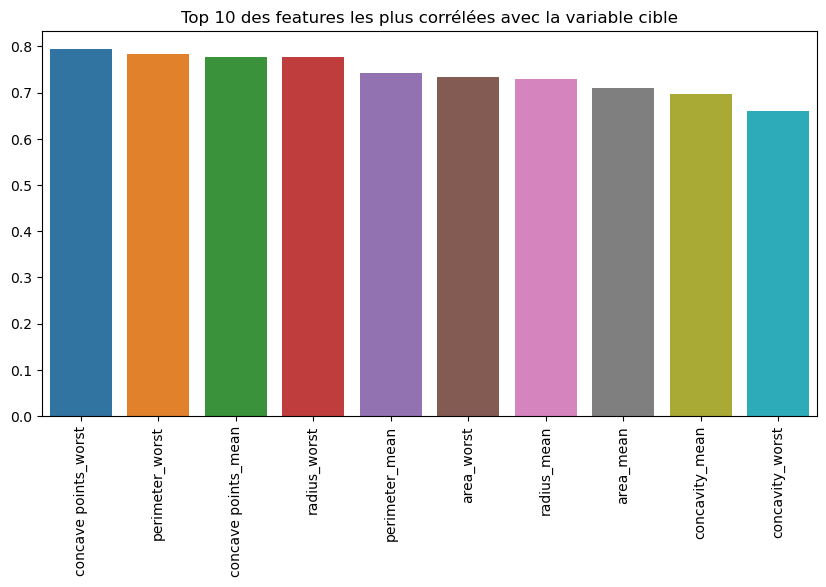

In [29]:
# Corrélation de toutes les colonnes avec la variable cible
correlation = correlation_matrix['diagnosis'].sort_values(ascending=False)

# Afficher les 10 features les plus corrélées (hors la cible elle-même)
top10_features = correlation.drop('diagnosis').head(10)
print(top10_features)

#bar plot des 10 features les plus corrélées avec la variable cible
plt.figure(figsize=(10,5))
sns.barplot(x=top10_features.index, y=top10_features.values)
plt.xticks(rotation=90)
plt.title('Top 10 des features les plus corrélées avec la variable cible')
plt.show()

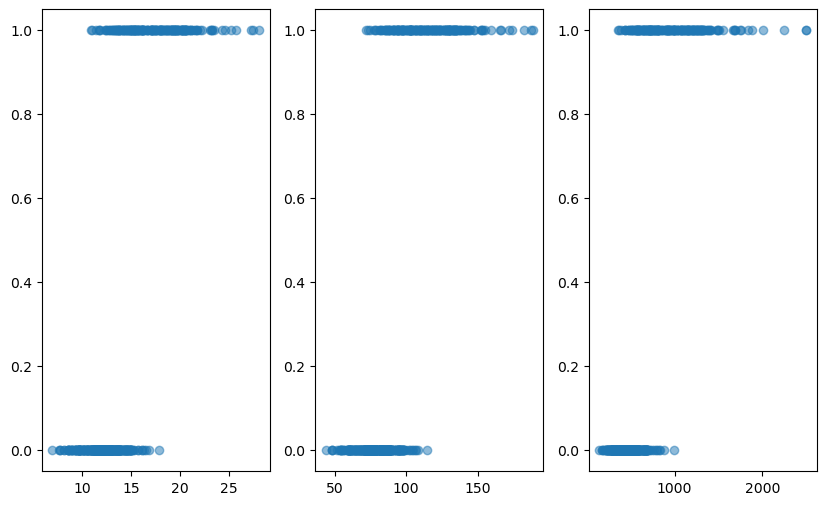

In [30]:
#Scatterplots des 3 paires de features les plus corrélées
plt.figure(figsize=(10,6))  
plt.subplot(1,3,1)
plt.scatter(df['radius_mean'], df['diagnosis'], alpha=0.5)
plt.subplot(1,3,2)
plt.scatter(df['perimeter_mean'], df['diagnosis'], alpha=0.5)
plt.subplot(1,3,3)
plt.scatter(df['area_mean'], df['diagnosis'], alpha=0.5)
plt.show()

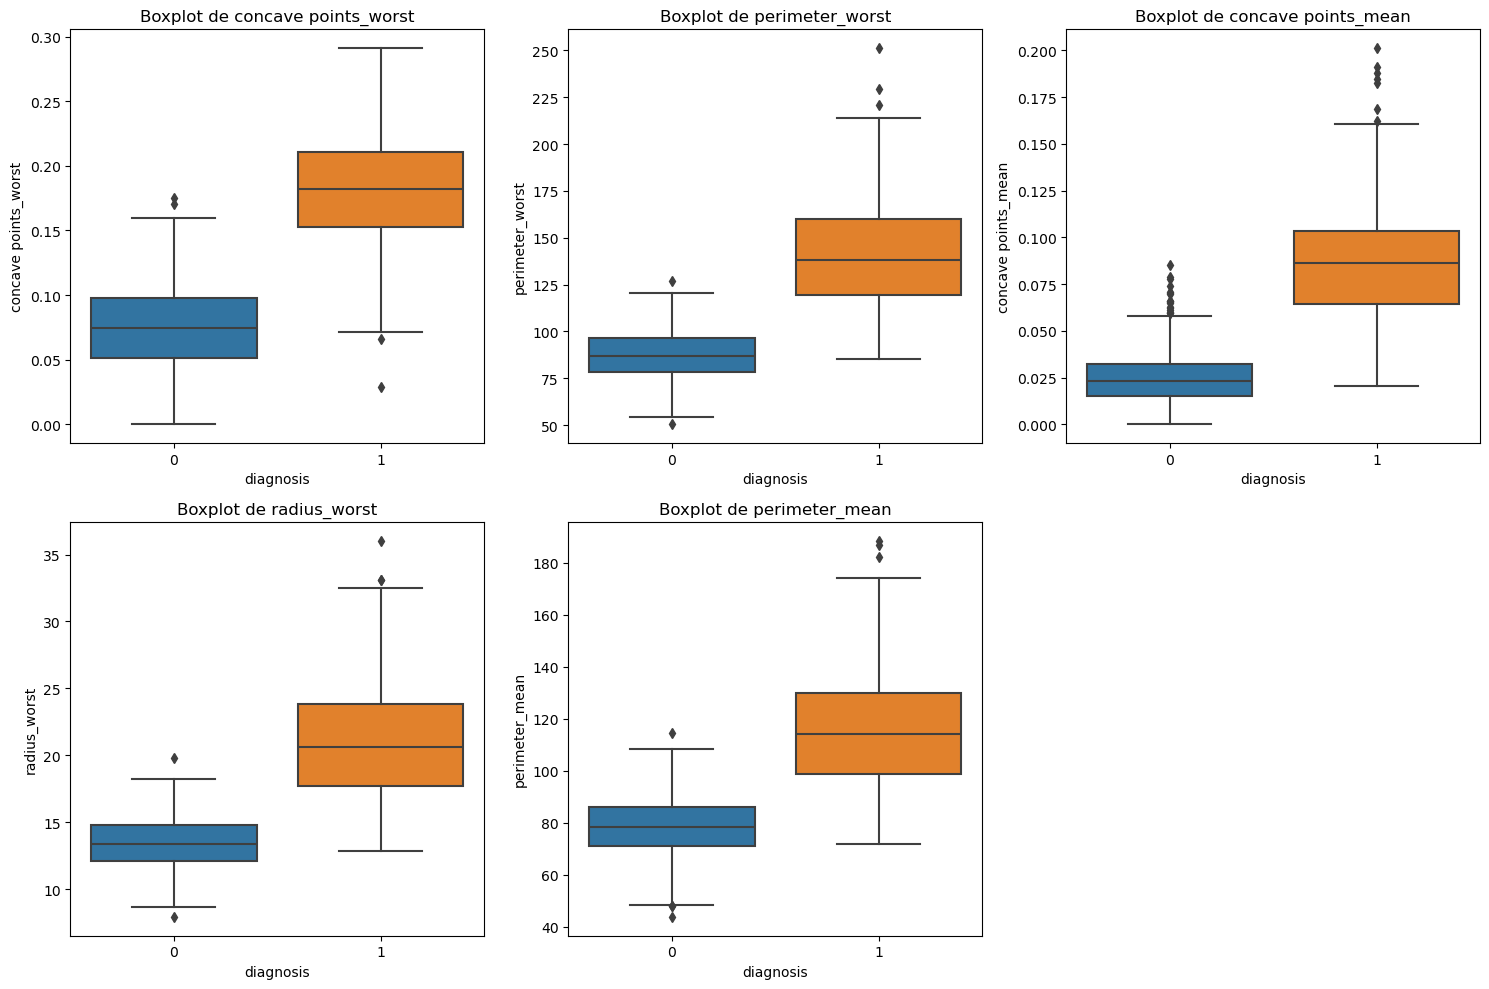

In [31]:
#Boxplots comparatifs pour les 5 features les plus discriminantes
top5_features = top10_features.head(5).index.to_list()
plt.figure(figsize=(15, 10))
for i, feature in enumerate(top5_features):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x='diagnosis', y=feature, data=df)
    plt.title(f'Boxplot de {feature}')
plt.tight_layout()
plt.show()

In [32]:
#T-tests pour vérifier les différences significatives entre classes
from scipy.stats import ttest_ind
top5_features = top10_features.head(5).index.to_list()
features = top5_features
benign = df[df['diagnosis'] == '0']
malignant = df[df['diagnosis'] == '1']
for feature in features:
    t_stat, p_value = ttest_ind(benign[feature], malignant[feature])
    print(f'Test t pour {feature}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}')

Test t pour concave points_worst: t-statistic = nan, p-value = nan
Test t pour perimeter_worst: t-statistic = nan, p-value = nan
Test t pour concave points_mean: t-statistic = nan, p-value = nan
Test t pour radius_worst: t-statistic = nan, p-value = nan
Test t pour perimeter_mean: t-statistic = nan, p-value = nan


In [33]:
#Moyennes et écarts-types par classe
df.groupby('diagnosis')[features].agg(['mean', 'std'])

concave points_worst           perimeter_worst             \
                          mean       std            mean        std   
diagnosis                                                             
0                     0.074444  0.035797       87.005938  13.527091   
1                     0.182237  0.046308      141.370330  29.457055   

          concave points_mean           radius_worst           perimeter_mean  \
                         mean       std         mean       std           mean   
diagnosis                                                                       
0                    0.025717  0.015909    13.379801  1.981368      78.075406   
1                    0.087990  0.034374    21.134811  4.283569     115.365377   

                      
                 std  
diagnosis             
0          11.807438  
1          21.854653

### Détection des outliers

Nous allons identifier les outliers dans les features les plus importantes à l'aide de la règle IQR (1.5 × IQR).  
Ces valeurs extrêmes correspondent majoritairement à des cas malins extrêmes et ne seront **pas supprimées** afin de conserver toutes les informations.  
Nous allons simplement les **marquer** pour pouvoir les visualiser et éventuellement les traiter (normalisation ou transformation) avant la modélisation.


In [34]:
#Identifier les outliers avec la règle IQR (1.5×IQR)
outlier_flags = pd.DataFrame(index=df.index)

for feature in features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outlier_flags[feature+'_outlier'] = (df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)

# Combien d'outliers par feature
print(outlier_flags.sum())

# Afficher les 5 premières lignes
outlier_flags.head()

df = pd.concat([df, outlier_flags], axis=1)

concave points_worst_outlier     0
perimeter_worst_outlier         15
concave points_mean_outlier     10
radius_worst_outlier            17
perimeter_mean_outlier          13
dtype: int64


### Stratégie pour les outliers

Les outliers identifiés correspondent majoritairement à des cas malins extrêmes.  
Pour cette raison, ils **ont été marqués mais non supprimés** afin de conserver toutes les informations importantes.  
Avant l'entraînement des modèles, les features seront **normalisées** pour réduire l'impact des valeurs extrêmes.


In [35]:
#Appliquer la stratégie choisie

#from sklearn.preprocessing import MinMaxScaler
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

In [36]:
df.head(20)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,concave points_worst_outlier,perimeter_worst_outlier,concave points_mean_outlier,radius_worst_outlier,perimeter_mean_outlier
0,1,17.99,10.38,1.269934,1001.0,0.11840,0.27760,0.30010,2.532475,0.2419,...,0.6656,0.7119,2.296076,0.4601,0.11890,False,False,False,False,False
1,1,20.57,17.77,1.685955,1326.0,0.08474,0.07864,0.08690,0.548144,0.1812,...,0.1866,0.2416,1.087084,0.2750,0.08902,False,False,False,False,False
2,1,19.69,21.25,1.566503,1203.0,0.10960,0.15990,0.19740,2.037231,0.2069,...,0.4245,0.4504,1.955000,0.3613,0.08758,False,False,False,False,False
3,1,11.42,20.38,-0.592687,386.1,0.14250,0.28390,0.24140,1.451707,0.2597,...,0.8663,0.6869,2.175786,0.6638,0.17300,False,False,False,False,False
4,1,20.29,14.34,1.776573,1297.0,0.10030,0.13280,0.19800,1.428493,0.1809,...,0.2050,0.4000,0.729259,0.2364,0.07678,False,False,False,False,False
5,1,12.45,15.70,-0.387148,477.1,0.12780,0.17000,0.15780,0.824656,0.2087,...,0.5249,0.5355,0.905888,0.3985,0.12440,False,False,False,False,False
6,1,18.25,19.98,1.138125,1040.0,0.09463,0.10900,0.11270,0.646935,0.1794,...,0.2576,0.3784,1.196716,0.3063,0.08368,False,False,False,False,False
7,1,13.71,20.83,-0.072867,577.9,0.11890,0.16450,0.09366,0.281950,0.2196,...,0.3682,0.2678,0.624196,0.3196,0.11510,False,False,False,False,False
8,1,13.00,21.82,-0.184080,519.8,0.12730,0.19320,0.18590,1.150692,0.2350,...,0.5401,0.5390,1.391616,0.4378,0.10720,False,False,False,False,False
9,1,12.46,24.04,-0.329482,475.9,0.11860,0.23960,0.22730,0.941760,0.2030,...,1.0580,1.1050,1.620015,0.4366,0.20750,False,False,False,False,False


### Stratégie appliquée aux outliers

Les outliers identifiés ont été **marqués mais non supprimés** afin de conserver toutes les informations.  
Ensuite, les features les plus importantes ont été **normalisées** (StandardScaler) pour réduire l’impact des valeurs extrêmes avant l’entraînement des modèles.


### Création de nouvelles features

Des features de ratio ont été créées pour capturer des relations entre les mesures des cellules :  
- `perimeter_area_ratio` : périmètre / surface, pour caractériser la forme  
- `area_radius_ratio` : surface / rayon, pour la taille relative  


In [37]:
#creation des features de ration 
df['radius_perimeter_ratio'] = df['radius_mean'] / df['perimeter_mean']
df['area_radius_ratio'] = df['area_mean'] / df['radius_mean']
df[['radius_perimeter_ratio', 'area_radius_ratio']].head()


,radius_perimeter_ratio,area_radius_ratio
0,14.166094,55.642023
1,12.200802,64.462810
2,12.569397,61.097004
3,-19.268175,33.809107
4,11.420864,63.923115


### Création d’interactions entre features

Des interactions ont été créées pour capturer des relations non-linéaires entre les mesures des cellules :  
- `texture_smoothness_interaction` = texture × smoothness  
- `perimeter_area_interaction` = perimeter × area  

Ces features permettent de mieux distinguer les cellules bénignes des malignes.


In [38]:
#creation des interactions entre features importantes
df['texture_smoothness_interaction'] = df['texture_mean'] * df['smoothness_mean']
df['perimeter_area_interaction'] = df['perimeter_mean'] * df['area_mean']

#  Afficher les 5 premières lignes des nouvelles features
df[['texture_smoothness_interaction', 'perimeter_area_interaction']].head() 


,texture_smoothness_interaction,perimeter_area_interaction
0,1.228992,1271.203622
1,1.505830,2235.575946
2,2.329000,1884.503265
3,2.904150,-228.836515
4,1.438302,2304.215377


### Normalisation des features

Les features numériques présentent des échelles très différentes et contiennent des valeurs extrêmes.  
Une **standardisation (StandardScaler)** a été appliquée afin de centrer les données (moyenne = 0) et de réduire leur dispersion (écart-type = 1).  
Cela permet d'améliorer la performance des modèles sensibles à l’échelle des variables.


In [39]:


# Liste des features numériques (sans la cible)
features = df.drop(columns=['diagnosis']).columns
x = df[features]
y = df['diagnosis']

#application de la standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

#recreation d'un DataFrame avec les features standardisées
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df.index)

#verification visuelle de la standardisation
X_scaled_df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,fractal_dimension_worst,concave points_worst_outlier,perimeter_worst_outlier,concave points_mean_outlier,radius_worst_outlier,perimeter_mean_outlier,radius_perimeter_ratio,area_radius_ratio,texture_smoothness_interaction,perimeter_area_interaction
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,569.0,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,569.000000
mean,-1.373633e-16,6.868164e-17,2.497514e-17,-2.185325e-16,-8.366672e-16,1.873136e-16,4.995028e-17,-4.995028e-17,1.748260e-16,4.745277e-16,...,-5.744282e-16,0.0,-1.248757e-17,-1.248757e-17,-2.809703e-17,-3.121893e-17,-1.248757e-17,3.996022e-16,-3.621395e-16,0.000000
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,0.0,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.601839e+00,0.0,-1.645473e-01,-1.337501e-01,-1.754910e-01,-1.529094e-01,-7.044045e+00,-2.065189e+00,-1.940948e+00,-0.595109
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.919118e-01,0.0,-1.645473e-01,-1.337501e-01,-1.754910e-01,-1.529094e-01,-1.900135e-01,-6.897530e-01,-7.252565e-01,-0.528308
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.164441e-01,0.0,-1.645473e-01,-1.337501e-01,-1.754910e-01,-1.529094e-01,-7.393912e-02,-2.159400e-01,-7.063573e-02,-0.397038
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,4.709834e-01,...,4.507624e-01,0.0,-1.645473e-01,-1.337501e-01,-1.754910e-01,-1.529094e-01,1.419122e-01,5.290259e-01,6.234310e-01,0.049322
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,4.910919e+00,...,6.846856e+00,0.0,6.077280e+00,7.476630e+00,5.698297e+00,6.539819e+00,1.071615e+01,4.271378e+00,4.101936e+00,7.952929


### Standardisation des features numériques

Toutes les features numériques ont été standardisées à l’aide du **StandardScaler**.  
Cette transformation permet de centrer les données (moyenne = 0) et de réduire leur dispersion (écart-type = 1),  
ce qui est essentiel pour les modèles sensibles à l’échelle des variables.


In [40]:
#selectionner uniquement les colonnes numériques
numeric_cols = X_scaled_df.select_dtypes(include=[np.number]).columns

#retirer la variable cible si elle est numérique
numeric_cols = numeric_cols.drop('diagnosis', errors='ignore')
numeric_cols

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst',
       'concave points_worst_outlier', 'perimeter_worst_outlier',
       'concave points_mean_outlier', 'radius_worst_outlier',
       'perimeter_mean_outlier', 'radius_perimeter_ratio', 'area_radius_ratio',
       'texture_smoothness_interaction', 'perimeter_area_interaction'],
      dtype='object')

In [41]:
scaler  = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
df[numeric_cols].describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,fractal_dimension_worst,concave points_worst_outlier,perimeter_worst_outlier,concave points_mean_outlier,radius_worst_outlier,perimeter_mean_outlier,radius_perimeter_ratio,area_radius_ratio,texture_smoothness_interaction,perimeter_area_interaction
count,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,...,5.690000e+02,569.0,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,5.690000e+02,569.000000
mean,-1.373633e-16,6.868164e-17,2.497514e-17,-2.185325e-16,-8.366672e-16,1.873136e-16,4.995028e-17,-4.995028e-17,1.748260e-16,4.745277e-16,...,-5.744282e-16,0.0,-1.248757e-17,-1.248757e-17,-2.809703e-17,-3.121893e-17,-1.248757e-17,3.996022e-16,-3.621395e-16,0.000000
std,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,...,1.000880e+00,0.0,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880e+00,1.000880
min,-2.029648e+00,-2.229249e+00,-1.984504e+00,-1.454443e+00,-3.112085e+00,-1.610136e+00,-1.114873e+00,-1.261820e+00,-2.744117e+00,-1.819865e+00,...,-1.601839e+00,0.0,-1.645473e-01,-1.337501e-01,-1.754910e-01,-1.529094e-01,-7.044045e+00,-2.065189e+00,-1.940948e+00,-0.595109
25%,-6.893853e-01,-7.259631e-01,-6.919555e-01,-6.671955e-01,-7.109628e-01,-7.470860e-01,-7.437479e-01,-7.379438e-01,-7.032397e-01,-7.226392e-01,...,-6.919118e-01,0.0,-1.645473e-01,-1.337501e-01,-1.754910e-01,-1.529094e-01,-1.900135e-01,-6.897530e-01,-7.252565e-01,-0.528308
50%,-2.150816e-01,-1.046362e-01,-2.359800e-01,-2.951869e-01,-3.489108e-02,-2.219405e-01,-3.422399e-01,-3.977212e-01,-7.162650e-02,-1.782793e-01,...,-2.164441e-01,0.0,-1.645473e-01,-1.337501e-01,-1.754910e-01,-1.529094e-01,-7.393912e-02,-2.159400e-01,-7.063573e-02,-0.397038
75%,4.693926e-01,5.841756e-01,4.996769e-01,3.635073e-01,6.361990e-01,4.938569e-01,5.260619e-01,6.469351e-01,5.307792e-01,4.709834e-01,...,4.507624e-01,0.0,-1.645473e-01,-1.337501e-01,-1.754910e-01,-1.529094e-01,1.419122e-01,5.290259e-01,6.234310e-01,0.049322
max,3.971288e+00,4.651889e+00,3.976130e+00,5.250529e+00,4.770911e+00,4.568425e+00,4.243589e+00,3.927930e+00,4.484751e+00,4.910919e+00,...,6.846856e+00,0.0,6.077280e+00,7.476630e+00,5.698297e+00,6.539819e+00,1.071615e+01,4.271378e+00,4.101936e+00,7.952929


Les données ont été séparées en un ensemble d’entraînement (80 %) et un ensemble de test (20 %).
Une stratification a été appliquée afin de conserver la même proportion de tumeurs bénignes et malignes
dans les deux ensembles, garantissant ainsi une évaluation fiable du modèle.


In [42]:
#Split train/test (80/20) avec stratification


# Features (X) et cible (y)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)   

In [43]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((455, 39), (114, 39), (455,), (114,))

In [44]:
print("Proportions globales :")
print(y.value_counts(normalize=True))

print("\nProportions train :")
print(y_train.value_counts(normalize=True))

print("\nProportions test :")
print(y_test.value_counts(normalize=True))


Proportions globales :
diagnosis
0    0.627417
1    0.372583
Name: proportion, dtype: float64

Proportions train :
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Proportions test :
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


### Sauvegarde des datasets préparés

Le dataset a été sauvegardé après nettoyage, standardisation et split train/test :
- `breast_cancer_clean.csv` : dataset complet
Cela permet de réutiliser les données sans refaire le preprocessing.


In [45]:
# Dataset complet avec toutes les features et la cible encodée
df.to_csv('breast_cancer_clean.csv', index=False)


In [46]:
#calcul de la matrice de correlation sur le dataset complet nettoyé
correlation_matrix = df.drop(columns=['diagnosis']).corr()

#selection des paires de features avec une correlation absolue > 0.9
high_correlation_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.9:
            pair = (correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j])
            high_correlation_pairs.append(pair)
high_correlation_pairs
#affichage des paires de features avec une correlation absolue > 0.9
for pair in high_correlation_pairs:
    print(f'Features: {pair[0]} et {pair[1]} - Corrélation: {pair[2]:.4f}')
    

Features: perimeter_mean et radius_mean - Corrélation: 0.9979
Features: area_mean et radius_mean - Corrélation: 0.9874
Features: area_mean et perimeter_mean - Corrélation: 0.9865
Features: concave points_mean et concavity_mean - Corrélation: 0.9214
Features: perimeter_se et radius_se - Corrélation: 0.9728
Features: area_se et radius_se - Corrélation: 0.9518
Features: area_se et perimeter_se - Corrélation: 0.9377
Features: radius_worst et radius_mean - Corrélation: 0.9695
Features: radius_worst et perimeter_mean - Corrélation: 0.9695
Features: radius_worst et area_mean - Corrélation: 0.9627
Features: texture_worst et texture_mean - Corrélation: 0.9120
Features: perimeter_worst et radius_mean - Corrélation: 0.9651
Features: perimeter_worst et perimeter_mean - Corrélation: 0.9704
Features: perimeter_worst et area_mean - Corrélation: 0.9591
Features: perimeter_worst et radius_worst - Corrélation: 0.9937
Features: area_worst et radius_mean - Corrélation: 0.9411
Features: area_worst et perim

In [47]:
# Supposons que radius_mean, perimeter_mean et area_mean sont très corrélées
# On peut garder radius_mean et supprimer les deux autres
features_selected = df.drop(columns=[
    'perimeter_mean', 'area_mean',
    'perimeter_worst', 'area_worst',
    'radius_worst'  # selon corrélation
])

to_drop = set()
for i, j, corr_val in high_correlation_pairs:
    if j not in to_drop:
        to_drop.add(i)
features_selected = df.drop(columns=list(to_drop))

features_selected.corr().max().max()

1.0